# Tarang ECG Classifier v6 — Phase A: Diagnostic Baseline

**Team Ocelleon — IoT Challenge 2026**

## Purpose of Phase A

Before changing the model, get true baseline numbers. Phase A applies 5 patches on top of v5:

| Patch | What it does | Why it matters |
|-------|--------------|----------------|
| A1 | Tune thresholds on VAL, freeze on TEST | Current v5 numbers are optimistic (leakage) |
| A2 | Force single-lead training (ch1 = ch0) | Match 1-lead hardware; eliminate train/serve skew |
| A3 | Add INCART DB as held-out cross-DB test | Detect memorization vs learning |
| A4 | Per-record F1 reporting | Find rhythm-specific failure modes |
| A5 | 2-beat / 1-beat / 0-beat lookahead test | Firmware delay spec validation |

## How to use this file

1. Open in VS Code or Jupyter (it's percent-format compatible).
2. Update `MITBIH_PATH`, `SVDB_PATH`, `INCART_PATH` in Cell 1.
3. Run end-to-end. Cells 1-16 reproduce v5 training (now with single-lead).
4. Cells 17-20 produce the Phase A diagnostic report.
5. Report back the 4 numbers in the final cell.

## What to report back after running

- MIT-BIH test macro F1 (post-leakage-fix)
- INCART macro F1 + generalization gap
- Worst 5 records + their F1 (rhythm-specific failure modes)
- 2-beat / 1-beat / 0-beat F1 triplet

These 4 numbers drive every Phase B decision.

In [1]:
# === Cell 1 — imports, paths, constants (PATCHED) ==========================
import os, json, subprocess, warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample_poly

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_curve, auc)

warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

# ── PATHS — edit these ────────────────────────────────────────────────────────
MITBIH_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0'
SVDB_PATH   = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-supraventricular-arrhythmia-database-1.0.0'
INCART_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/incartdb'

OUTPUTS_DIR          = 'outputs_v6_phaseA'
GATE_CHECKPOINT      = f'{OUTPUTS_DIR}/tarang_gate_best.keras'
SV_CHECKPOINT        = f'{OUTPUTS_DIR}/tarang_sv_best.keras'
GATE_TFLITE_PATH     = f'{OUTPUTS_DIR}/tarang_gate_int8.tflite'
SV_TFLITE_PATH       = f'{OUTPUTS_DIR}/tarang_sv_int8.tflite'
GATE_HEADER_PATH     = f'{OUTPUTS_DIR}/tarang_gate_model.h'
SV_HEADER_PATH       = f'{OUTPUTS_DIR}/tarang_sv_model.h'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── WINDOW — 250 Hz, firmware-accurate ───────────────────────────────────────
FS          = 250
WINDOW_PRE  = 65
WINDOW_POST = 65
WINDOW_LEN  = WINDOW_PRE + WINDOW_POST   # 130 samples = 520 ms

FS_ORIG_MITBIH = 360
FS_ORIG_INCART = 500  # INCART is 500 Hz — resample_poly(25, 50)

CONFIDENCE_THRESHOLD_GATE = 0.60
CONFIDENCE_THRESHOLD_SV   = 0.50

# ── PHASE A PATCH A2 ─────────────────────────────────────────────────────────
# Force single-lead training to match 1-lead deployment hardware.
# If True, ch1 is always duplicated from ch0 for ALL records
# (including 2-lead MIT-BIH), eliminating train/serve skew.
FORCE_SINGLE_LEAD = True

print(f"TensorFlow : {tf.__version__}")
print(f"Target FS  : {FS} Hz")
print(f"Window     : {WINDOW_LEN} samples = {WINDOW_LEN/FS*1000:.1f} ms")
print(f"FORCE_SINGLE_LEAD = {FORCE_SINGLE_LEAD}  ← Phase A2 patch")
print(f"INCART path : {INCART_PATH}  (exists={os.path.isdir(INCART_PATH)})")

GPU memory growth enabled for 1 GPU(s)
TensorFlow : 2.10.1
Target FS  : 250 Hz
Window     : 130 samples = 520.0 ms
FORCE_SINGLE_LEAD = True  ← Phase A2 patch
INCART path : C:/MMD Public/Hackathons/Team Ocelleon/dataset/incartdb  (exists=True)


In [44]:
# === Cell 2 — AAMI mapping & splits (unchanged from v5) ====================
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'V',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'V', 'S']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS
                        and r not in MITBIH_VAL_RECORDS]

SVDB_RECORDS = [f'{i}' for i in range(800, 895)]

# INCART DB: 75 records (I01..I75), 500 Hz, 12-lead
INCART_RECORDS = [f'I{i:02d}' for i in range(1, 76)]

print(f"MIT-BIH train/val/test : {len(MITBIH_TRAIN_RECORDS)}/{len(MITBIH_VAL_RECORDS)}/{len(MITBIH_TEST_RECORDS)}")
print(f"SVDB  (S+V boost only) : {len(SVDB_RECORDS)} records")
print(f"INCART (held-out test) : {len(INCART_RECORDS)} records  ← Phase A3")

MIT-BIH train/val/test : 18/4/26
SVDB  (S+V boost only) : 95 records
INCART (held-out test) : 75 records  ← Phase A3


In [22]:
# === Cell 3 — RR features (unchanged from v5) ==============================
def rolling_window_normalize(signal, window_samples=7500):
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks, beat_idx):
    """7 RR features. Matches firmware tarang_ai_process()."""
    n = len(peaks)
    i = beat_idx

    prev_idx = max(0, i-1)
    next_idx = min(n-1, i+1)
    rr_prev  = (peaks[i]      - peaks[prev_idx]) / FS
    rr_next  = (peaks[next_idx] - peaks[i])      / FS
    rr_ratio = rr_prev / max(rr_next, 1e-4)

    lo = max(0, i-2); hi = min(n-1, i+2)
    local_rrs = np.diff(peaks[lo:hi+1]).astype(np.float32) / FS
    rr_mean_5 = float(np.mean(local_rrs)) if len(local_rrs) > 0 else rr_prev
    rr_std_5  = float(np.std(local_rrs))  if len(local_rrs) > 0 else 0.0

    compensatory_ratio = rr_next / max(rr_prev, 1e-4)
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)

    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                     compensatory_ratio, prematurity_index], dtype=np.float32)


RR_FEATURE_NAMES = ['rr_prev','rr_next','rr_ratio','rr_mean_5','rr_std_5',
                    'compensatory_ratio','prematurity_index']

# ── PHASE A PATCH A5 (PART 1) ────────────────────────────────────────────────
# New function: same as compute_rr_features but with selectable lookahead.
# Used by the robustness test to simulate firmware at different delays.
def compute_rr_features_lookahead(peaks, beat_idx, lookahead='full'):
    """
    Recompute RR features at different lookahead levels.
    Simulates what firmware can compute at each delay.

    lookahead:
      'full'   = use peaks[i-2..i+2]  (offline, 2-beat delay before classifying beat i)
      '1beat'  = use peaks[i-2..i+1]  (1-beat delay; peak[i+2] not yet arrived)
      '0beat'  = use peaks[i-2..i]    (no delay; rr_next unknown)
    """
    n = len(peaks)
    i = beat_idx
    prev_idx = max(0, i-1)

    if lookahead == 'full':
        next_idx = min(n-1, i+1)
        lo, hi = max(0, i-2), min(n-1, i+2)
    elif lookahead == '1beat':
        next_idx = min(n-1, i+1)
        lo, hi = max(0, i-2), min(n-1, i+1)
    elif lookahead == '0beat':
        next_idx = i
        lo, hi = max(0, i-2), i
    else:
        raise ValueError(f"Unknown lookahead: {lookahead}")

    rr_prev = (peaks[i] - peaks[prev_idx]) / FS
    rr_next = (peaks[next_idx] - peaks[i]) / FS if next_idx > i else 0.0
    rr_ratio = rr_prev / max(rr_next, 1e-4) if rr_next > 0 else 0.0

    if hi > lo:
        local_rrs = np.diff(peaks[lo:hi+1]).astype(np.float32) / FS
        rr_mean_5 = float(np.mean(local_rrs)) if len(local_rrs) > 0 else rr_prev
        rr_std_5  = float(np.std(local_rrs))  if len(local_rrs) > 0 else 0.0
    else:
        rr_mean_5 = rr_prev
        rr_std_5  = 0.0

    compensatory_ratio = rr_next / max(rr_prev, 1e-4) if rr_next > 0 else 1.0
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)

    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                     compensatory_ratio, prematurity_index], dtype=np.float32)


print(f"RR features: {len(RR_FEATURE_NAMES)}")
print(f"Phase A5: compute_rr_features_lookahead() added for firmware delay simulation")

RR features: 7
Phase A5: compute_rr_features_lookahead() added for firmware delay simulation


In [23]:
# === Cell 4 — load_records (PATCHED for A2 + A5) ===========================
# Patches:
#   A2: honor FORCE_SINGLE_LEAD — always duplicate ch1 = ch0 when True
#   A5: also return per-beat peak sample index (needed for lookahead test)
#   A3: support arbitrary source FS (INCART is 500 Hz, MIT-BIH/SVDB are 360 Hz)

def load_records(db_path, record_list, source_tag, two_channel=True,
                 classes_filter=None, source_fs=360):
    """
    Load and resample beats from MIT-BIH / SVDB / INCART to 250 Hz.

    source_fs: original sample rate of the source DB (360 for MIT-BIH/SVDB, 500 for INCART)
    """
    if classes_filter is None:
        classes_filter = CLASSES_TO_USE

    # Resample ratio to 250 Hz
    if source_fs == 360:
        up, down = 25, 36
    elif source_fs == 500:
        up, down = 1, 2
    elif source_fs == 250:
        up, down = 1, 1
    else:
        # GCD-based fallback
        from math import gcd
        g = gcd(250, source_fs)
        up, down = 250 // g, source_fs // g

    all_beats, all_rr, all_labels, all_recs, all_peaks = [], [], [], [], []
    channel_log = {}

    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')

            n_ch = record.p_signal.shape[1]
            channel_log[rec_str] = n_ch

            # ── Resample ch0 ─────────────────────────────────────────────────
            sig_ch0_orig = record.p_signal[:, 0]
            if up == 1 and down == 1:
                sig_ch0_250 = sig_ch0_orig.astype(np.float32)
            else:
                sig_ch0_250 = resample_poly(sig_ch0_orig, up=up, down=down).astype(np.float32)

            # ── A2 PATCH: honor FORCE_SINGLE_LEAD ────────────────────────────
            if two_channel and n_ch > 1 and not FORCE_SINGLE_LEAD:
                if up == 1 and down == 1:
                    sig_ch1_250 = record.p_signal[:, 1].astype(np.float32)
                else:
                    sig_ch1_250 = resample_poly(record.p_signal[:, 1],
                                                up=up, down=down).astype(np.float32)
                is_duplicated = False
            else:
                sig_ch1_250 = sig_ch0_250.copy()
                is_duplicated = True

            # ── Rescale peak indices ─────────────────────────────────────────
            peaks_orig = annotation.sample
            scale = 250.0 / source_fs
            peaks_250 = np.round(peaks_orig * scale).astype(int)
            syms      = annotation.symbol

            sig_len_250 = len(sig_ch0_250)

            # ── Normalize ────────────────────────────────────────────────────
            ecg_ch0 = rolling_window_normalize(sig_ch0_250)
            ecg_ch1 = rolling_window_normalize(sig_ch1_250)

            valid_idxs = [i for i, s in enumerate(syms)
                          if BEAT_MAP.get(s, None) in classes_filter]

            beats_this = 0
            for idx in valid_idxs:
                peak   = peaks_250[idx]
                mapped = BEAT_MAP[syms[idx]]

                if (peak - WINDOW_PRE < 0 or
                        peak + WINDOW_POST >= sig_len_250):
                    continue

                beat = np.stack([
                    ecg_ch0[peak - WINDOW_PRE : peak + WINDOW_POST],
                    ecg_ch1[peak - WINDOW_PRE : peak + WINDOW_POST],
                ], axis=-1).astype(np.float32)

                if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                    continue

                rr = compute_rr_features(peaks_250, idx)

                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(mapped)
                all_recs.append(f'{source_tag}_{rec_str}')
                all_peaks.append(int(peak))   # ← A5 patch: per-beat peak sample
                beats_this += 1

            dup_tag = ' [CH1=DUP]' if is_duplicated else ''
            print(f"  {source_tag}/{rec_str}: {beats_this} beats  ({n_ch}ch{dup_tag})")

        except Exception as ex:
            print(f"  {source_tag}/{rec_str}: FAILED — {ex}")

    n_dup = sum(1 for v in channel_log.values() if v == 1)
    print(f"  Summary: {len(channel_log)} records, {n_dup} single-lead (ch1 duplicated)")

    return (
        np.array(all_beats,  dtype=np.float32),
        np.array(all_rr,     dtype=np.float32),
        np.array(all_labels, dtype=object),
        np.array(all_recs,   dtype=object),
        np.array(all_peaks,  dtype=np.int32),   # ← A5 patch
    )


print("load_records() — PATCHED for A2 (single-lead) + A3 (multi-FS) + A5 (peaks)")

load_records() — PATCHED for A2 (single-lead) + A3 (multi-FS) + A5 (peaks)


In [24]:
# === Cell 5 — load MIT-BIH (unchanged logic, new unpack signature) =========
print("Loading MIT-BIH Arrhythmia Database (all records, 360→250 Hz)...")
mb_beats, mb_rr, mb_labels, mb_recs, mb_peaks = load_records(
    MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True, source_fs=360
)
print(f"\nMIT-BIH total: {mb_beats.shape}  classes={Counter(mb_labels)}")

Loading MIT-BIH Arrhythmia Database (all records, 360→250 Hz)...
  mitbih/100: 2271 beats  (2ch [CH1=DUP])
  mitbih/101: 1862 beats  (2ch [CH1=DUP])
  mitbih/102: 103 beats  (2ch [CH1=DUP])
  mitbih/103: 2084 beats  (2ch [CH1=DUP])
  mitbih/104: 165 beats  (2ch [CH1=DUP])
  mitbih/105: 2567 beats  (2ch [CH1=DUP])
  mitbih/106: 2027 beats  (2ch [CH1=DUP])
  mitbih/107: 59 beats  (2ch [CH1=DUP])
  mitbih/108: 1762 beats  (2ch [CH1=DUP])
  mitbih/109: 2531 beats  (2ch [CH1=DUP])
  mitbih/111: 2124 beats  (2ch [CH1=DUP])
  mitbih/112: 2539 beats  (2ch [CH1=DUP])
  mitbih/113: 1794 beats  (2ch [CH1=DUP])
  mitbih/114: 1879 beats  (2ch [CH1=DUP])
  mitbih/115: 1952 beats  (2ch [CH1=DUP])
  mitbih/116: 2411 beats  (2ch [CH1=DUP])
  mitbih/117: 1534 beats  (2ch [CH1=DUP])
  mitbih/118: 2277 beats  (2ch [CH1=DUP])
  mitbih/119: 1987 beats  (2ch [CH1=DUP])
  mitbih/121: 1863 beats  (2ch [CH1=DUP])
  mitbih/122: 2476 beats  (2ch [CH1=DUP])
  mitbih/123: 1517 beats  (2ch [CH1=DUP])
  mitbih/124: 1

In [6]:
# === Cell 6 — load SVDB (unchanged logic, new unpack signature) ============
print("Loading SVDB (Supraventricular Arrhythmia Database, S+V beats only)...")
svdb_ok = os.path.isdir(SVDB_PATH)

if svdb_ok:
    sv_beats, sv_rr, sv_labels, sv_recs, sv_peaks = load_records(
        SVDB_PATH, SVDB_RECORDS, 'svdb',
        two_channel=False,
        classes_filter=['S', 'V'],
        source_fs=360
    )
    print(f"\nSVDB (S+V only): {sv_beats.shape}  classes={Counter(sv_labels)}")
else:
    print(f"SVDB not found at {SVDB_PATH}")
    sv_beats  = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
    sv_rr     = np.empty((0, 7),             dtype=np.float32)
    sv_labels = np.array([], dtype=object)
    sv_recs   = np.array([], dtype=object)
    sv_peaks  = np.array([], dtype=np.int32)

Loading SVDB (Supraventricular Arrhythmia Database, S+V beats only)...
  svdb/800: 37 beats  (2ch [CH1=DUP])
  svdb/801: 334 beats  (2ch [CH1=DUP])
  svdb/802: 85 beats  (2ch [CH1=DUP])
  svdb/803: 144 beats  (2ch [CH1=DUP])
  svdb/804: 181 beats  (2ch [CH1=DUP])
  svdb/805: 207 beats  (2ch [CH1=DUP])
  svdb/806: 71 beats  (2ch [CH1=DUP])
  svdb/807: 29 beats  (2ch [CH1=DUP])
  svdb/808: 28 beats  (2ch [CH1=DUP])
  svdb/809: 112 beats  (2ch [CH1=DUP])
  svdb/810: 64 beats  (2ch [CH1=DUP])
  svdb/811: 30 beats  (2ch [CH1=DUP])
  svdb/812: 84 beats  (2ch [CH1=DUP])
  svdb/813: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\813.hea'
  svdb/814: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\814.hea'
  svdb/815: FAILED — [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\

In [7]:
# === Cell 7 — splits (unchanged from v5) ===================================
test_mask  = np.array([r.startswith('mitbih_') and
                        int(r.split('_')[1]) in MITBIH_TEST_RECORDS
                        for r in mb_recs])
val_mask   = np.array([r.startswith('mitbih_') and
                        int(r.split('_')[1]) in MITBIH_VAL_RECORDS
                        for r in mb_recs])
train_mask = ~test_mask & ~val_mask

mb_X_train, mb_X_val, mb_X_test = mb_beats[train_mask],  mb_beats[val_mask],  mb_beats[test_mask]
mb_rr_train, mb_rr_val, mb_rr_test = mb_rr[train_mask],  mb_rr[val_mask],    mb_rr[test_mask]
mb_y_train, mb_y_val, mb_y_test = mb_labels[train_mask], mb_labels[val_mask], mb_labels[test_mask]
mb_peaks_test = mb_peaks[test_mask]   # ← A5 patch

# GATE DATASET
gate_X_train = mb_X_train
gate_rr_train= mb_rr_train
gate_y_train = (mb_y_train != 'N').astype(np.int32)

gate_X_val   = mb_X_val
gate_rr_val  = mb_rr_val
gate_y_val   = (mb_y_val != 'N').astype(np.int32)

gate_X_test  = mb_X_test
gate_rr_test = mb_rr_test
gate_y_test  = (mb_y_test != 'N').astype(np.int32)

# SV DISCRIMINATOR DATASET
sv_mask_train = mb_y_train != 'N'
sv_mask_val   = mb_y_val   != 'N'
sv_mask_test  = mb_y_test  != 'N'

sv_le = LabelEncoder()
sv_le.fit(['S', 'V'])

sv_X_train  = np.concatenate([mb_X_train[sv_mask_train],  sv_beats], axis=0)
sv_rr_train = np.concatenate([mb_rr_train[sv_mask_train], sv_rr],    axis=0)
sv_y_train  = sv_le.transform(np.concatenate([
    mb_y_train[sv_mask_train], sv_labels], axis=0))

sv_X_val    = mb_X_val[sv_mask_val]
sv_rr_val   = mb_rr_val[sv_mask_val]
sv_y_val    = sv_le.transform(mb_y_val[sv_mask_val])

sv_X_test   = mb_X_test[sv_mask_test]
sv_rr_test  = mb_rr_test[sv_mask_test]
sv_y_test   = sv_le.transform(mb_y_test[sv_mask_test])

print("GATE: train={:,}  val={:,}  test={:,}".format(
    len(gate_X_train), len(gate_X_val), len(gate_X_test)))
print("SV  : train={:,}  val={:,}  test={:,}".format(
    len(sv_X_train), len(sv_X_val), len(sv_X_test)))

GATE: train=34,467  val=8,492  test=58,467
SV  : train=25,496  val=475  test=7,001


In [26]:
# === Cell 8 — RR normalization (unchanged) =================================
RR_MEAN = mb_rr_train.mean(axis=0)
RR_STD  = mb_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8

def normalize_rr(X_rr):
    return ((X_rr - RR_MEAN) / RR_STD).astype(np.float32)

gate_rr_train_n = normalize_rr(gate_rr_train)
gate_rr_val_n   = normalize_rr(gate_rr_val)
gate_rr_test_n  = normalize_rr(gate_rr_test)

sv_rr_train_n   = normalize_rr(sv_rr_train)
sv_rr_val_n     = normalize_rr(sv_rr_val)
sv_rr_test_n    = normalize_rr(sv_rr_test)

print("RR normalization stats:")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name:<22}: mean={RR_MEAN[i]:.5f}  std={RR_STD[i]:.5f}")

RR normalization stats:
  [0] rr_prev               : mean=0.78341  std=0.25890
  [1] rr_next               : mean=0.78580  std=0.25690
  [2] rr_ratio              : mean=3.02262  std=125.20856
  [3] rr_mean_5             : mean=0.78138  std=0.21611
  [4] rr_std_5              : mean=0.06558  std=0.12966
  [5] compensatory_ratio    : mean=1.04208  std=0.35935
  [6] prematurity_index     : mean=1.00325  std=0.15255


In [27]:
# === Cell 9 — augmentation (unchanged from v5) =============================
# Will be overhauled in Phase B (B3).
def augment_batch(X_ecg, X_rr, class_name, n_copies):
    n = len(X_ecg)
    ecg_list, rr_list = [], []
    t_arr = np.linspace(0, 2*np.pi, WINDOW_LEN)

    for _ in range(n_copies):
        a = X_ecg.copy()
        a *= np.random.uniform(0.85, 1.15, (n, 1, 1))
        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.12, n)
        wander = (amps[:, None] * np.sin(freqs[:, None] * t_arr[None, :]))[:, :, None]
        a += wander
        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape).astype(np.float32)
        shifts = np.random.randint(-8, 9, n)
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i], axis=0)
        if class_name == 'S':
            a[:, :28, :] *= np.random.uniform(0.4, 1.6, (n, 1, 1))
        ecg_list.append(a.astype(np.float32))

        rr = X_rr.copy()
        if class_name == 'S':
            rr[:, 0] *= np.random.uniform(0.6, 0.95, n)
            rr[:, 2]  = rr[:, 0] / np.maximum(rr[:, 1], 1e-4)
            rr[:, 4] *= np.random.uniform(1.1, 1.5, n)
            rr[:, 5]  = rr[:, 1] / np.maximum(rr[:, 0], 1e-4)
            rr[:, 5]  = np.clip(rr[:, 5], 0.8, 1.5)
            rr[:, 6]  = rr[:, 0] / np.maximum(rr[:, 3], 1e-4)
        elif class_name == 'V':
            rr[:, 1] *= np.random.uniform(1.1, 1.3, n)
            rr[:, 4] *= np.random.uniform(1.0, 1.3, n)
            rr[:, 5]  = rr[:, 1] / np.maximum(rr[:, 0], 1e-4)
            rr[:, 5]  = np.clip(rr[:, 5], 1.5, 3.0)
            rr[:, 6]  = rr[:, 0] / np.maximum(rr[:, 3], 1e-4)
        rr *= np.random.uniform(0.97, 1.03, rr.shape)
        rr  = np.clip(rr, 0.0, 5.0).astype(np.float32)
        rr_list.append(rr)

    return (np.concatenate(ecg_list, axis=0),
            np.concatenate(rr_list,  axis=0))


def build_augmented_dataset(X_ecg, X_rr_raw, y_labels, aug_copies_dict,
                             label_classes, normalize_fn):
    ecg_list = [X_ecg]
    rr_list  = [X_rr_raw]
    y_list   = [y_labels]
    for ci, cname in enumerate(label_classes):
        n_copies = aug_copies_dict.get(cname, 0)
        if n_copies == 0:
            continue
        mask = (y_labels == ci)
        if not np.any(mask):
            continue
        aug_ecg, aug_rr = augment_batch(X_ecg[mask], X_rr_raw[mask], cname, n_copies)
        ecg_list.append(aug_ecg)
        rr_list.append(aug_rr)
        y_list.append(np.full(len(aug_ecg), ci, dtype=y_labels.dtype))
        print(f"  {cname}: {np.sum(mask)} → +{len(aug_ecg)} augmented")
    X_aug   = np.concatenate(ecg_list, axis=0)
    rr_aug  = np.concatenate(rr_list,  axis=0)
    y_aug   = np.concatenate(y_list,   axis=0)
    rr_aug_n= normalize_fn(rr_aug)
    idx = np.random.permutation(len(X_aug))
    return X_aug[idx], rr_aug_n[idx], y_aug[idx]

print("Augmentation functions defined (v5 — will be overhauled in Phase B3).")

Augmentation functions defined (v5 — will be overhauled in Phase B3).


In [28]:
# === Cell 10 — GATE augmentation (unchanged from v5) =======================
print("GATE DATASET AUGMENTATION")
gate_ecg_aug_list = [gate_X_train]
gate_rr_aug_list  = [gate_rr_train]
gate_y_aug_list   = [gate_y_train]

abn_mask = gate_y_train == 1
aug_ecg, aug_rr = augment_batch(gate_X_train[abn_mask],
                                 gate_rr_train[abn_mask], 'V', n_copies=4)
gate_ecg_aug_list.append(aug_ecg)
gate_rr_aug_list.append(aug_rr)
gate_y_aug_list.append(np.ones(len(aug_ecg), dtype=np.int32))

gate_X_train_aug  = np.concatenate(gate_ecg_aug_list, axis=0)
gate_rr_train_aug = np.concatenate(gate_rr_aug_list,  axis=0)
gate_y_train_aug  = np.concatenate(gate_y_aug_list,   axis=0)
gate_rr_train_aug_n = normalize_rr(gate_rr_train_aug)

idx = np.random.permutation(len(gate_X_train_aug))
gate_X_train_aug    = gate_X_train_aug[idx]
gate_rr_train_aug_n = gate_rr_train_aug_n[idx]
gate_y_train_aug    = gate_y_train_aug[idx]

print(f"After : N={np.sum(gate_y_train_aug==0):,}  Abn={np.sum(gate_y_train_aug==1):,}")

GATE DATASET AUGMENTATION
After : N=31,125  Abn=16,710


In [29]:
# === Cell 11 — SV augmentation (unchanged from v5) =========================
print("SV DISCRIMINATOR DATASET AUGMENTATION")
sv_X_train_aug, sv_rr_train_aug_n, sv_y_train_aug = build_augmented_dataset(
    sv_X_train, sv_rr_train, sv_y_train,
    aug_copies_dict={'S': 10, 'V': 4},
    label_classes=sv_le.classes_,
    normalize_fn=normalize_rr
)
print(f"After : S={np.sum(sv_y_train_aug==0):,}  V={np.sum(sv_y_train_aug==1):,}")

SV DISCRIMINATOR DATASET AUGMENTATION
  S: 13889 → +138890 augmented
  V: 11607 → +46428 augmented
After : S=152,779  V=58,035


In [30]:
# === Cell 12 — Gate CNN architecture (unchanged from v5) ===================
def build_gate_cnn(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(16, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.3)(merged)

    out = tf.keras.layers.Dense(1, activation='sigmoid', name='gate_out')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=out, name='Tarang_Gate')

gate_model = build_gate_cnn()
gate_model.summary()
print(f"Gate parameters: {gate_model.count_params():,}")

Model: "Tarang_Gate"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 separable_conv1d_18 (Separable  (None, 130, 16)     46          ['ecg_input[0][0]']              
 Conv1D)                                                                                          
                                                                                                  
 batch_normalization_24 (BatchN  (None, 130, 16)     64          ['separable_conv1d_18[0][0]']    
 ormalization)                                                                                    
                                                                                        

In [31]:
# === Cell 13 — SV CNN architecture (unchanged from v5) =====================
def build_sv_cnn(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    x = tf.keras.layers.SeparableConv1D(
        64, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.15)(x)

    x = tf.keras.layers.SeparableConv1D(
        64, 3, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    out = tf.keras.layers.Dense(1, activation='sigmoid', name='sv_out')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=out, name='Tarang_SV')

sv_model = build_sv_cnn()
sv_model.summary()
print(f"SV parameters: {sv_model.count_params():,}")

Model: "Tarang_SV"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 separable_conv1d_20 (Separable  (None, 130, 16)     46          ['ecg_input[0][0]']              
 Conv1D)                                                                                          
                                                                                                  
 batch_normalization_27 (BatchN  (None, 130, 16)     64          ['separable_conv1d_20[0][0]']    
 ormalization)                                                                                    
                                                                                          

In [32]:
# === Cell 14 — Loss + LR schedule (unchanged from v5) ======================
class BinaryFocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true  = tf.cast(tf.reshape(y_true, [-1, 1]), tf.float32)
        bce     = -y_true * tf.math.log(y_pred) - (1-y_true) * tf.math.log(1-y_pred)
        pt      = tf.where(tf.equal(y_true, 1), y_pred, 1-y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), self.alpha, 1-self.alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1-pt, self.gamma) * bce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'alpha': self.alpha, 'gamma': self.gamma})
        return cfg


class BinaryF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, pos_label_name='Abnormal', **kwargs):
        super().__init__(**kwargs)
        self.val_x, self.val_y = val_data
        self.pos_label_name    = pos_label_name

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.val_x, batch_size=128, verbose=0).flatten()
        preds = (probs > 0.5).astype(int)
        f1    = f1_score(self.val_y, preds, average='macro', zero_division=0)
        logs['val_macro_f1'] = f1

WARMUP_EPOCHS = 2
MAX_LR        = 5e-4
TOTAL_EPOCHS  = 150

def lr_schedule(epoch):
    if epoch < WARMUP_EPOCHS:
        return MAX_LR * (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(TOTAL_EPOCHS - WARMUP_EPOCHS, 1)
    return 1e-6 + 0.5 * (MAX_LR - 1e-6) * (1 + np.cos(np.pi * progress))

print("Losses and LR schedule defined.")

Losses and LR schedule defined.


In [15]:
# === Cell 15 — Train GATE (unchanged from v5) ==============================
print("TRAINING GATE MODEL")
gate_model = build_gate_cnn()
gate_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=MAX_LR, clipnorm=1.0),
    loss=BinaryFocalLoss(alpha=0.30, gamma=2.0),
    metrics=['accuracy']
)
gate_f1_cb = BinaryF1Callback(
    val_data=([gate_X_val, gate_rr_val_n], gate_y_val),
    pos_label_name='Abnormal'
)
gate_callbacks = [
    gate_f1_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', patience=25, mode='max',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        GATE_CHECKPOINT, monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    ),
]
gate_history = gate_model.fit(
    [gate_X_train_aug, gate_rr_train_aug_n], gate_y_train_aug,
    validation_data=([gate_X_val, gate_rr_val_n], gate_y_val),
    epochs=TOTAL_EPOCHS,
    batch_size=64,
    callbacks=gate_callbacks,
    verbose=1
)
with open(f'{OUTPUTS_DIR}/gate_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in gate_history.history.items()}, f)
print("Gate training complete.")

TRAINING GATE MODEL
Epoch 1/150
747/748 [============================>.] - ETA: 0s - loss: 0.0581 - accuracy: 0.8069
Epoch 1: val_macro_f1 improved from -inf to 0.85923, saving model to outputs_v6_phaseA\tarang_gate_best.keras
748/748 [==============================] - 20s 15ms/step - loss: 0.0581 - accuracy: 0.8070 - val_loss: 0.0256 - val_accuracy: 0.9699 - val_macro_f1: 0.8592 - lr: 2.5000e-04
Epoch 2/150
748/748 [==============================] - ETA: 0s - loss: 0.0318 - accuracy: 0.8987
Epoch 2: val_macro_f1 improved from 0.85923 to 0.86838, saving model to outputs_v6_phaseA\tarang_gate_best.keras
748/748 [==============================] - 11s 14ms/step - loss: 0.0318 - accuracy: 0.8987 - val_loss: 0.0168 - val_accuracy: 0.9716 - val_macro_f1: 0.8684 - lr: 5.0000e-04
Epoch 3/150
746/748 [============================>.] - ETA: 0s - loss: 0.0251 - accuracy: 0.9323
Epoch 3: val_macro_f1 did not improve from 0.86838
748/748 [==============================] - 9s 12ms/step - loss: 0.025

In [16]:
# === Cell 16 — Train SV (unchanged from v5) ================================
print("TRAINING SV DISCRIMINATOR")
sv_model = build_sv_cnn()
sv_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=MAX_LR, clipnorm=1.0),
    loss=BinaryFocalLoss(alpha=0.40, gamma=2.0),
    metrics=['accuracy']
)
sv_f1_cb = BinaryF1Callback(
    val_data=([sv_X_val, sv_rr_val_n], sv_y_val),
    pos_label_name='V'
)
sv_callbacks = [
    sv_f1_cb,
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', patience=25, mode='max',
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        SV_CHECKPOINT, monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    ),
]
sv_history = sv_model.fit(
    [sv_X_train_aug, sv_rr_train_aug_n], sv_y_train_aug,
    validation_data=([sv_X_val, sv_rr_val_n], sv_y_val),
    epochs=TOTAL_EPOCHS,
    batch_size=32,
    callbacks=sv_callbacks,
    verbose=1
)
with open(f'{OUTPUTS_DIR}/sv_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in sv_history.history.items()}, f)
print("SV training complete.")

TRAINING SV DISCRIMINATOR
Epoch 1/150
6586/6588 [============================>.] - ETA: 0s - loss: 0.0428 - accuracy: 0.8912
Epoch 1: val_macro_f1 improved from -inf to 0.71760, saving model to outputs_v6_phaseA\tarang_sv_best.keras
6588/6588 [==============================] - 102s 15ms/step - loss: 0.0428 - accuracy: 0.8912 - val_loss: 0.0550 - val_accuracy: 0.7347 - val_macro_f1: 0.7176 - lr: 2.5000e-04
Epoch 2/150
6585/6588 [============================>.] - ETA: 0s - loss: 0.0187 - accuracy: 0.9520
Epoch 2: val_macro_f1 improved from 0.71760 to 0.84712, saving model to outputs_v6_phaseA\tarang_sv_best.keras
6588/6588 [==============================] - 99s 15ms/step - loss: 0.0187 - accuracy: 0.9520 - val_loss: 0.0419 - val_accuracy: 0.8716 - val_macro_f1: 0.8471 - lr: 5.0000e-04
Epoch 3/150
6587/6588 [============================>.] - ETA: 0s - loss: 0.0149 - accuracy: 0.9631
Epoch 3: val_macro_f1 did not improve from 0.84712
6588/6588 [==============================] - 100s 15ms/s

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



6588/6588 [==============================] - ETA: 0s - loss: 0.0095 - accuracy: 0.9776
Epoch 12: val_macro_f1 did not improve from 0.91283
6588/6588 [==============================] - 1355s 206ms/step - loss: 0.0095 - accuracy: 0.9776 - val_loss: 0.0321 - val_accuracy: 0.9116 - val_macro_f1: 0.8898 - lr: 4.9546e-04
Epoch 13/150
6584/6588 [============================>.] - ETA: 0s - loss: 0.0094 - accuracy: 0.9776
Epoch 13: val_macro_f1 did not improve from 0.91283
6588/6588 [==============================] - 86s 13ms/step - loss: 0.0094 - accuracy: 0.9776 - val_loss: 0.0349 - val_accuracy: 0.8884 - val_macro_f1: 0.8619 - lr: 4.9440e-04
Epoch 14/150
6586/6588 [============================>.] - ETA: 0s - loss: 0.0093 - accuracy: 0.9777
Epoch 14: val_macro_f1 did not improve from 0.91283
6588/6588 [==============================] - 88s 13ms/step - loss: 0.0093 - accuracy: 0.9777 - val_loss: 0.0398 - val_accuracy: 0.8863 - val_macro_f1: 0.8432 - lr: 4.9323e-04
Epoch 15/150
6587/6588 [=====

GATE EVALUATION — Phase A1: threshold tuned on VAL, applied to TEST
Tuned on VAL  : thr=0.50  val_macro_f1=0.000  (recall floor=0.92)
Frozen on TEST: macro_f1=0.851

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97     51466
    Abnormal       0.81      0.68      0.74      7001

    accuracy                           0.94     58467
   macro avg       0.88      0.83      0.85     58467
weighted avg       0.94      0.94      0.94     58467



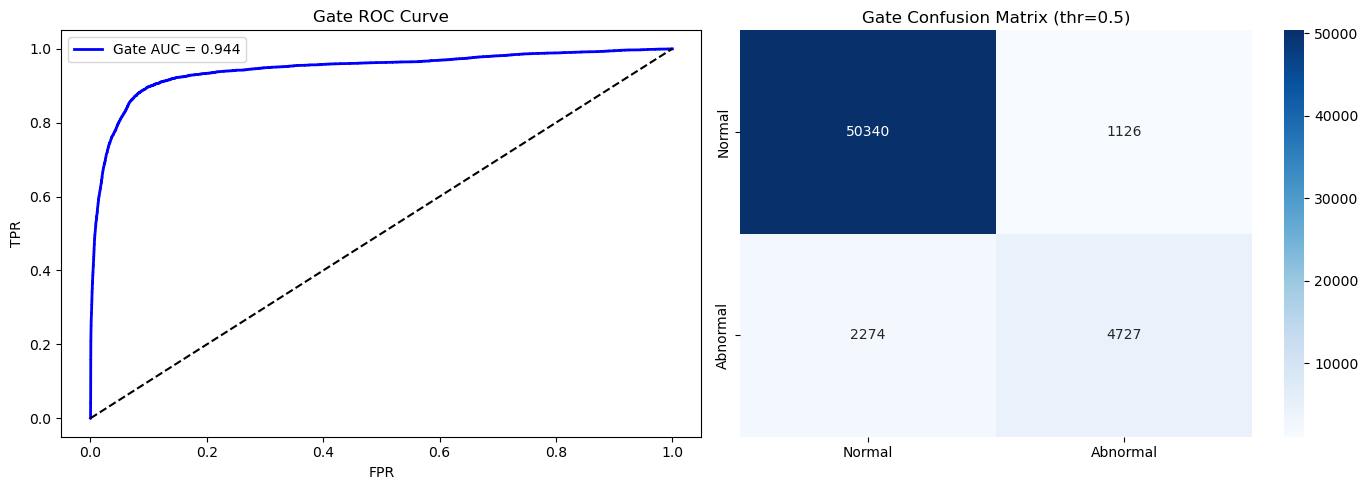

Gate AUC: 0.944


In [33]:
# === Cell 17 — GATE EVAL (PATCHED A1: tune on VAL, freeze on TEST) =========
print("=" * 60)
print("GATE EVALUATION — Phase A1: threshold tuned on VAL, applied to TEST")
print("=" * 60)

gate_model = build_gate_cnn()
gate_model.load_weights(GATE_CHECKPOINT)

# Predict on BOTH val and test
gate_probs_val  = gate_model.predict([gate_X_val, gate_rr_val_n],
                                      batch_size=128, verbose=0).flatten()
gate_probs_test = gate_model.predict([gate_X_test, gate_rr_test_n],
                                      batch_size=128, verbose=0).flatten()

# ── TUNE THRESHOLD ON VAL ──────────────────────────────────────────────────
ABN_RECALL_FLOOR = 0.92
best_gate_thr    = 0.5
best_gate_f1_val = 0.0

for thr in np.arange(0.05, 0.95, 0.01):
    preds_val = (gate_probs_val > thr).astype(int)
    abn_recall_val = (np.sum((gate_y_val==1) & (preds_val==1)) /
                      max(np.sum(gate_y_val==1), 1))
    if abn_recall_val < ABN_RECALL_FLOOR:
        continue
    f1_val = f1_score(gate_y_val, preds_val, average='macro', zero_division=0)
    if f1_val > best_gate_f1_val:
        best_gate_f1_val = f1_val
        best_gate_thr    = round(thr, 2)

# ── FROZEN THRESHOLD APPLIED TO TEST ───────────────────────────────────────
gate_preds_test = (gate_probs_test > best_gate_thr).astype(int)
gate_f1_test    = f1_score(gate_y_test, gate_preds_test,
                            average='macro', zero_division=0)

print(f"Tuned on VAL  : thr={best_gate_thr:.2f}  val_macro_f1={best_gate_f1_val:.3f}  (recall floor={ABN_RECALL_FLOOR})")
print(f"Frozen on TEST: macro_f1={gate_f1_test:.3f}")
print()
print(classification_report(gate_y_test, gate_preds_test,
                             target_names=['Normal', 'Abnormal']))

fpr, tpr, _ = roc_curve(gate_y_test, gate_probs_test)
roc_auc = auc(fpr, tpr)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'Gate AUC = {roc_auc:.3f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('Gate ROC Curve')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()

cm = confusion_matrix(gate_y_test, gate_preds_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Abnormal'],
            yticklabels=['Normal','Abnormal'], ax=axes[1])
axes[1].set_title(f'Gate Confusion Matrix (thr={best_gate_thr})')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/gate_evaluation.png', dpi=150)
plt.show()
print(f"Gate AUC: {roc_auc:.3f}")

SV EVALUATION — Phase A1: threshold tuned on VAL, applied to TEST
Tuned on VAL  : thr=0.45  val_macro_f1=0.918  (V recall floor=0.92)
Frozen on TEST: macro_f1=0.768

              precision    recall  f1-score   support

           S       0.64      0.56      0.60       961
           V       0.93      0.95      0.94      6040

    accuracy                           0.90      7001
   macro avg       0.79      0.75      0.77      7001
weighted avg       0.89      0.90      0.89      7001



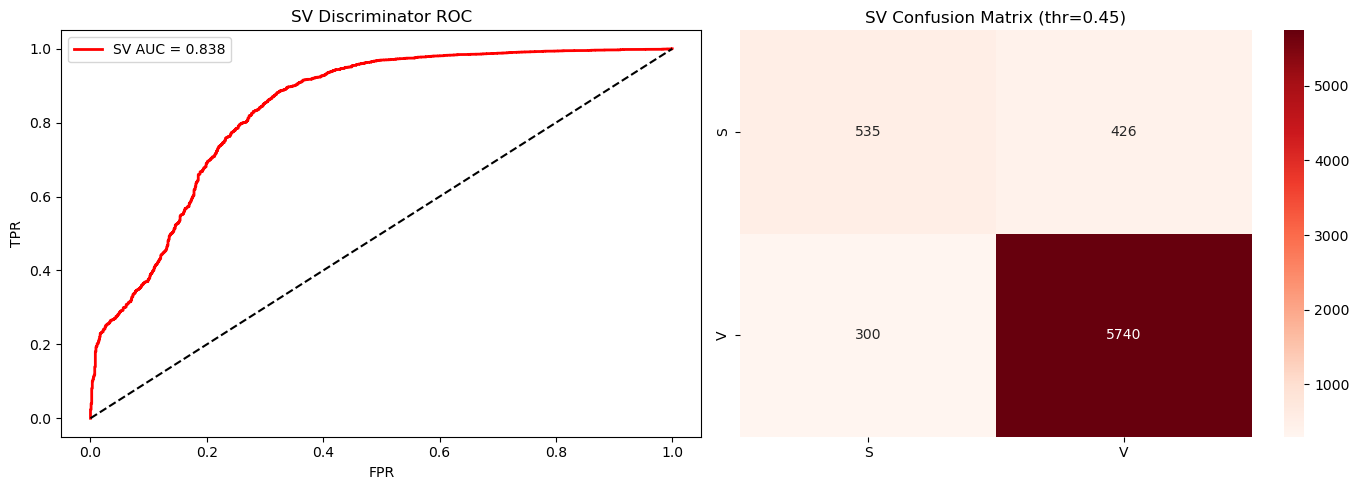

SV AUC: 0.838


In [34]:
# === Cell 18 — SV EVAL (PATCHED A1: tune on VAL, freeze on TEST) ===========
print("=" * 60)
print("SV EVALUATION — Phase A1: threshold tuned on VAL, applied to TEST")
print("=" * 60)

sv_model = build_sv_cnn()
sv_model.load_weights(SV_CHECKPOINT)

sv_probs_val  = sv_model.predict([sv_X_val, sv_rr_val_n],
                                  batch_size=128, verbose=0).flatten()
sv_probs_test = sv_model.predict([sv_X_test, sv_rr_test_n],
                                  batch_size=128, verbose=0).flatten()

# ── TUNE ON VAL ────────────────────────────────────────────────────────────
V_RECALL_FLOOR = 0.92
best_sv_thr    = 0.5
best_sv_f1_val = 0.0

for thr in np.arange(0.05, 0.95, 0.01):
    preds_val = (sv_probs_val > thr).astype(int)
    v_recall_val = (np.sum((sv_y_val==1) & (preds_val==1)) /
                    max(np.sum(sv_y_val==1), 1))
    if v_recall_val < V_RECALL_FLOOR:
        continue
    f1_val = f1_score(sv_y_val, preds_val, average='macro', zero_division=0)
    if f1_val > best_sv_f1_val:
        best_sv_f1_val = f1_val
        best_sv_thr    = round(thr, 2)

# ── FROZEN ON TEST ─────────────────────────────────────────────────────────
sv_preds_test = (sv_probs_test > best_sv_thr).astype(int)
sv_f1_test    = f1_score(sv_y_test, sv_preds_test,
                          average='macro', zero_division=0)

print(f"Tuned on VAL  : thr={best_sv_thr:.2f}  val_macro_f1={best_sv_f1_val:.3f}  (V recall floor={V_RECALL_FLOOR})")
print(f"Frozen on TEST: macro_f1={sv_f1_test:.3f}")
print()
print(classification_report(sv_y_test, sv_preds_test, target_names=['S', 'V']))

fpr_sv, tpr_sv, _ = roc_curve(sv_y_test, sv_probs_test)
roc_auc_sv = auc(fpr_sv, tpr_sv)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_sv, tpr_sv, 'r-', linewidth=2, label=f'SV AUC = {roc_auc_sv:.3f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('SV Discriminator ROC')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()

cm_sv = confusion_matrix(sv_y_test, sv_preds_test)
sns.heatmap(cm_sv, annot=True, fmt='d', cmap='Reds',
            xticklabels=['S','V'], yticklabels=['S','V'], ax=axes[1])
axes[1].set_title(f'SV Confusion Matrix (thr={best_sv_thr})')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/sv_evaluation.png', dpi=150)
plt.show()
print(f"SV AUC: {roc_auc_sv:.3f}")

CASCADE END-TO-END EVALUATION (Phase A1: frozen thresholds)
              precision    recall  f1-score   support

           N       0.96      0.98      0.97     51466
           S       0.15      0.11      0.12       961
           V       0.84      0.71      0.77      6040

    accuracy                           0.94     58467
   macro avg       0.65      0.60      0.62     58467
weighted avg       0.93      0.94      0.93     58467

Cascade Macro F1: 0.620
  F1 N: 0.967  [PASS]
  F1 S: 0.123  [NEEDS WORK]
  F1 V: 0.769  [NEEDS WORK]

PER-RECORD CASCADE F1 — identify rhythm-specific failures

 Rec      F1      n  distribution
------------------------------------------------------------
  115  0.333   1952  {'N': 1952}  <- WORST
  118  0.384   2277  {'N': 2165, 'V': 16, 'S': 96}  <- WORST
  201  0.435   1963  {'N': 1635, 'S': 128, 'V': 200}  <- WORST
  112  0.444   2539  {'N': 2537, 'S': 2}  <- WORST
  202  0.449   2136  {'N': 2061, 'V': 20, 'S': 55}  <- WORST
  208  0.493   2951  {'

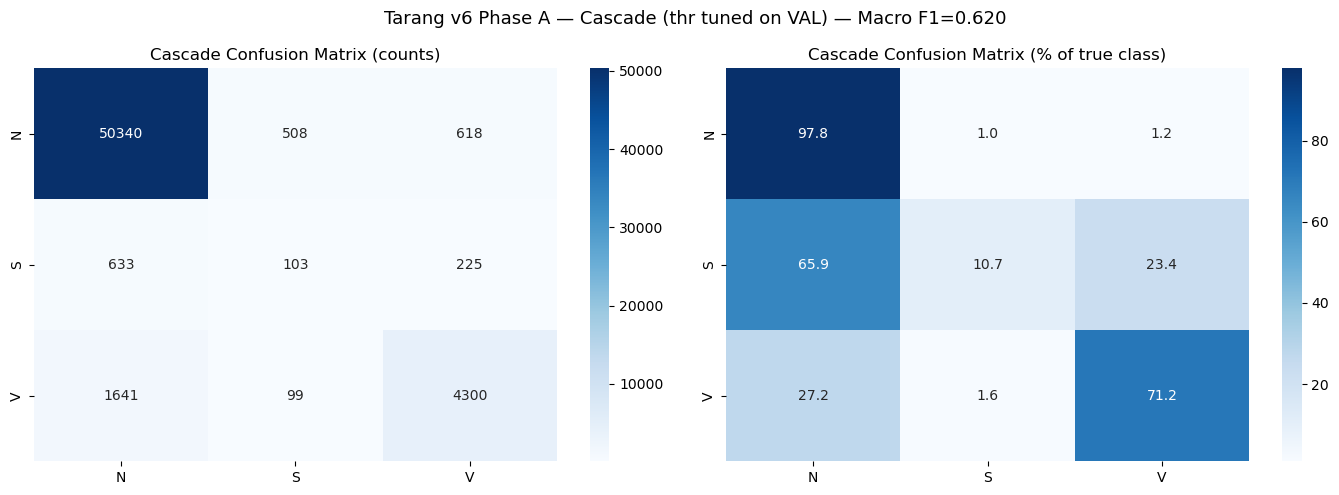

In [35]:
# === Cell 19 — CASCADE END-TO-END + PER-RECORD F1 (PATCHED A4) =============
print("=" * 60)
print("CASCADE END-TO-END EVALUATION (Phase A1: frozen thresholds)")
print("=" * 60)

full_X_test  = mb_X_test
full_rr_test = gate_rr_test_n
full_y_test  = mb_y_test

gate_probs_full = gate_model.predict([full_X_test, full_rr_test],
                                      batch_size=128, verbose=0).flatten()
gate_preds_full = (gate_probs_full > best_gate_thr).astype(int)

abn_mask     = gate_preds_full == 1
cascade_pred = np.full(len(full_y_test), 'N', dtype=object)

if np.any(abn_mask):
    sv_probs_cascade = sv_model.predict(
        [full_X_test[abn_mask], full_rr_test[abn_mask]],
        batch_size=128, verbose=0).flatten()
    sv_preds_cascade = (sv_probs_cascade > best_sv_thr).astype(int)
    cascade_pred[abn_mask] = np.where(sv_preds_cascade == 1, 'V', 'S')

print(classification_report(full_y_test, cascade_pred, target_names=['N','S','V']))

macro_f1 = f1_score(full_y_test, cascade_pred, average='macro',
                    labels=['N','S','V'], zero_division=0)
per_class = f1_score(full_y_test, cascade_pred, average=None,
                     labels=['N','S','V'], zero_division=0)
print(f"Cascade Macro F1: {macro_f1:.3f}")
for cls, f1_val in zip(['N','S','V'], per_class):
    status = 'PASS' if f1_val >= 0.85 else 'NEEDS WORK'
    print(f"  F1 {cls}: {f1_val:.3f}  [{status}]")

# ── A4 PATCH: PER-RECORD F1 ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PER-RECORD CASCADE F1 — identify rhythm-specific failures")
print("=" * 60)

test_rec_tags = mb_recs[test_mask]
per_record_f1 = []
for rec_id in MITBIH_TEST_RECORDS:
    rec_mask = np.array([r == f'mitbih_{rec_id}' for r in test_rec_tags])
    if rec_mask.sum() == 0:
        continue
    rec_y = full_y_test[rec_mask]
    rec_p = cascade_pred[rec_mask]
    rec_f1 = f1_score(rec_y, rec_p, average='macro',
                      labels=['N','S','V'], zero_division=0)
    cls_dist = Counter(rec_y)
    per_record_f1.append((rec_id, rec_f1, int(rec_mask.sum()), dict(cls_dist)))

per_record_f1.sort(key=lambda x: x[1])
print(f"\n{'Rec':>4}  {'F1':>6}  {'n':>5}  distribution")
print("-" * 60)
for rec_id, f1, n, dist in per_record_f1:
    flag = '  <- WORST' if f1 < 0.5 else ''
    print(f"  {rec_id:>3}  {f1:.3f}  {n:>5}  {dist}{flag}")

print(f"\nWorst 5 records (rhythm-specific failure modes — focus Phase B3 augmentation here):")
for rec_id, f1, n, dist in per_record_f1[:5]:
    print(f"  Rec {rec_id}: F1={f1:.3f}  n={n}  dist={dist}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_cas = confusion_matrix(full_y_test, cascade_pred, labels=['N','S','V'])
cm_pct = cm_cas.astype(float) / cm_cas.sum(axis=1)[:,None] * 100
sns.heatmap(cm_cas, annot=True, fmt='d', cmap='Blues',
            xticklabels=['N','S','V'], yticklabels=['N','S','V'], ax=axes[0])
axes[0].set_title('Cascade Confusion Matrix (counts)')
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['N','S','V'], yticklabels=['N','S','V'], ax=axes[1])
axes[1].set_title('Cascade Confusion Matrix (% of true class)')
plt.suptitle(f'Tarang v6 Phase A — Cascade (thr tuned on VAL) — Macro F1={macro_f1:.3f}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/cascade_confusion_matrix.png', dpi=150)
plt.show()

In [45]:
# === NEW Cell 19b — INCART cross-DB eval (A3) ==============================
print("=" * 60)
print("CROSS-DATABASE EVAL — INCART DB (held-out, never trained)")
print("=" * 60)

if not os.path.isdir(INCART_PATH):
    print(f"INCART not found at {INCART_PATH}")
    print("Download with: wfdb.dl_database('incartdb', dl_dir=INCART_PATH)")
    print("Skipping cross-DB eval. Install INCART before reporting Phase A numbers.")
    inc_macro = None
else:
    in_beats, in_rr, in_labels, in_recs, in_peaks = load_records(
        INCART_PATH, INCART_RECORDS, 'incart',
        two_channel=True,
        source_fs=500  # INCART is 500 Hz
    )
    in_rr_n = normalize_rr(in_rr)

    # Filter to N/S/V (INCART has F, Q, and other beats)
    keep = np.isin(in_labels, ['N', 'S', 'V'])
    in_beats_k  = in_beats[keep]
    in_rr_n_k   = in_rr_n[keep]
    in_labels_k = in_labels[keep]
    print(f"INCART: {len(in_labels)} total beats, {keep.sum()} N/S/V retained")
    print(f"  Class distribution: {Counter(in_labels_k)}")

    # Cascade inference with FROZEN thresholds from Phase A1
    gate_probs_inc = gate_model.predict([in_beats_k, in_rr_n_k],
                                         batch_size=128, verbose=0).flatten()
    gate_preds_inc = (gate_probs_inc > best_gate_thr).astype(int)

    cascade_pred_inc = np.full(len(in_labels_k), 'N', dtype=object)
    abn_inc = gate_preds_inc == 1
    if np.any(abn_inc):
        sv_probs_inc = sv_model.predict([in_beats_k[abn_inc], in_rr_n_k[abn_inc]],
                                         batch_size=128, verbose=0).flatten()
        sv_preds_inc = (sv_probs_inc > best_sv_thr).astype(int)
        cascade_pred_inc[abn_inc] = np.where(sv_preds_inc == 1, 'V', 'S')

    print()
    print(classification_report(in_labels_k, cascade_pred_inc,
                                 target_names=['N','S','V'], zero_division=0))

    inc_macro = f1_score(in_labels_k, cascade_pred_inc,
                          average='macro', labels=['N','S','V'], zero_division=0)
    inc_per   = f1_score(in_labels_k, cascade_pred_inc,
                          average=None, labels=['N','S','V'], zero_division=0)

    print("=" * 60)
    print("PHASE A3 — CROSS-DB GENERALIZATION SUMMARY")
    print("=" * 60)
    print(f"  MIT-BIH test macro F1 : {macro_f1:.3f}")
    print(f"  INCART      macro F1 : {inc_macro:.3f}")
    print(f"  Generalization gap    : {macro_f1 - inc_macro:+.3f}")
    print()
    print("  Interpretation:")
    gap = macro_f1 - inc_macro
    if gap > 0.15:
        print("    > 0.15 gap → SIGNIFICANT memorization. Phase B MUST add INCART-like records")
        print("                  to training or augment harder before any clinical claim.")
    elif gap > 0.05:
        print("    0.05-0.15 gap → moderate. Some memorization; address in Phase B3 augmentation.")
    else:
        print("    < 0.05 gap → healthy generalization. Model is learning, not memorizing.")
    print()
    for cls, f1_val in zip(['N','S','V'], inc_per):
        print(f"  INCART F1 {cls}: {f1_val:.3f}")

CROSS-DATABASE EVAL — INCART DB (held-out, never trained)
  incart/I01: 2756 beats  (12ch [CH1=DUP])
  incart/I02: 2673 beats  (12ch [CH1=DUP])
  incart/I03: 2451 beats  (12ch [CH1=DUP])
  incart/I04: 2422 beats  (12ch [CH1=DUP])
  incart/I05: 1775 beats  (12ch [CH1=DUP])
  incart/I06: 2492 beats  (12ch [CH1=DUP])
  incart/I07: 2704 beats  (12ch [CH1=DUP])
  incart/I08: 2129 beats  (12ch [CH1=DUP])
  incart/I09: 2988 beats  (12ch [CH1=DUP])
  incart/I10: 3680 beats  (12ch [CH1=DUP])
  incart/I11: 2081 beats  (12ch [CH1=DUP])
  incart/I12: 2807 beats  (12ch [CH1=DUP])
  incart/I13: 2023 beats  (12ch [CH1=DUP])
  incart/I14: 1864 beats  (12ch [CH1=DUP])
  incart/I15: 2633 beats  (12ch [CH1=DUP])
  incart/I16: 1522 beats  (12ch [CH1=DUP])
  incart/I17: 1672 beats  (12ch [CH1=DUP])
  incart/I18: 3083 beats  (12ch [CH1=DUP])
  incart/I19: 2062 beats  (12ch [CH1=DUP])
  incart/I20: 2650 beats  (12ch [CH1=DUP])
  incart/I21: 2183 beats  (12ch [CH1=DUP])
  incart/I22: 3126 beats  (12ch [CH1=DU

In [46]:
# === Cell 20 — LOOKAHEAD ROBUSTNESS TEST (PATCHED A5) ======================
# Now tests 2-beat / 1-beat / 0-beat lookahead (replaces v5's rr_next-only test)
#
# What this measures:
#   2-beat = firmware waits for peak[i+2] before classifying beat i  → matches offline
#   1-beat = firmware waits for peak[i+1] only                       → rr_mean_5/std_5 degraded
#   0-beat = firmware classifies immediately on peak[i]              → rr_next=0 (the v5 test)

print("=" * 60)
print("LOOKAHEAD ROBUSTNESS TEST — Phase A5")
print("Simulates firmware at 3 delay levels (validates 2-beat ring buffer spec)")
print("=" * 60)

# Re-extract test beats with RR features at each lookahead level.
# We rebuild the per-record peaks from disk and recompute RR features.
def rebuild_rr_for_test_records(test_records, db_path, source_fs, lookahead):
    """Recompute (N, 7) RR features for the test set at given lookahead."""
    out_rr = []
    for rec_id in test_records:
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_id}')
            annotation = wfdb.rdann(f'{db_path}/{rec_id}', 'atr')
            peaks_orig = annotation.sample
            scale = 250.0 / source_fs
            peaks_250 = np.round(peaks_orig * scale).astype(int)
            syms = annotation.symbol

            sig_ch0_250 = resample_poly(record.p_signal[:, 0],
                                         up=25, down=36).astype(np.float32)
            sig_len_250 = len(sig_ch0_250)

            for idx, sym in enumerate(syms):
                if BEAT_MAP.get(sym, None) not in ['N','S','V']:
                    continue
                peak = peaks_250[idx]
                if peak - WINDOW_PRE < 0 or peak + WINDOW_POST >= sig_len_250:
                    continue
                rr = compute_rr_features_lookahead(peaks_250, idx, lookahead)
                out_rr.append(rr)
        except Exception as e:
            print(f"  Rec {rec_id}: FAILED — {e}")
    return np.array(out_rr, dtype=np.float32)


print("Recomputing RR features at 3 lookahead levels (may take ~30s)...")
rr_2beat = rebuild_rr_for_test_set(MITBIH_TEST_RECORDS, MITBIH_PATH, 360, 'full')
rr_1beat = rebuild_rr_for_test_set(MITBIH_TEST_RECORDS, MITBIH_PATH, 360, '1beat')
rr_0beat = rebuild_rr_for_test_set(MITBIH_TEST_RECORDS, MITBIH_PATH, 360, '0beat')

# Sanity: row counts must match the test set size
assert len(rr_2beat) == len(full_X_test), \
    f"Row count mismatch: {len(rr_2beat)} vs {len(full_X_test)} (test set). " \
    "Filter ordering in rebuild_rr_for_test_records may have drifted."

# Normalize each with the SAME training stats
rr_2beat_n = normalize_rr(rr_2beat)
rr_1beat_n = normalize_rr(rr_1beat)
rr_0beat_n = normalize_rr(rr_0beat)


def cascade_f1_with_rr(X_ecg, X_rr_n, y_true):
    gp = gate_model.predict([X_ecg, X_rr_n], batch_size=128, verbose=0).flatten()
    gp = (gp > best_gate_thr).astype(int)
    pred = np.full(len(y_true), 'N', dtype=object)
    abn = gp == 1
    if np.any(abn):
        sp = sv_model.predict([X_ecg[abn], X_rr_n[abn]],
                               batch_size=128, verbose=0).flatten()
        pred[abn] = np.where((sp > best_sv_thr), 'V', 'S')
    return f1_score(y_true, pred, average='macro',
                    labels=['N','S','V'], zero_division=0)


f1_2beat = cascade_f1_with_rr(full_X_test, rr_2beat_n, full_y_test)
f1_1beat = cascade_f1_with_rr(full_X_test, rr_1beat_n, full_y_test)
f1_0beat = cascade_f1_with_rr(full_X_test, rr_0beat_n, full_y_test)

print()
print("=" * 60)
print("PHASE A5 — LOOKAHEAD SENSITIVITY")
print("=" * 60)
print(f"  2-beat lookahead (offline match) : F1 = {f1_2beat:.3f}  (baseline)")
print(f"  1-beat lookahead (peak[i+1] only): F1 = {f1_1beat:.3f}  drop = {f1_2beat-f1_1beat:+.3f}")
print(f"  0-beat lookahead (no future)     : F1 = {f1_0beat:.3f}  drop = {f1_2beat-f1_0beat:+.3f}")
print()
print("Firmware spec implication:")
if f1_2beat - f1_1beat < 0.03:
    print("  → 1-beat delay is acceptable (saves ~0.85s vs 2-beat at 70 bpm)")
    print("  → BUT verify rr_mean_5/rr_std_5 computation in firmware ring buffer")
elif f1_2beat - f1_1beat < 0.08:
    print("  → 1-beat delay costs moderate F1; 2-beat recommended for clinical use")
    print("  → Ring buffer MUST hold peak[i+2] before firing inference on beat i")
else:
    print("  → 1-beat delay unacceptable; 2-beat is hard requirement")
    print("  → Ring buffer spec: hold 3 R-peak timestamps + 2 ECG windows (≈ 560 B)")
print()
print("Decision matrix:")
print("  2-beat delay (~1.7s @ 70 bpm) → use full RR features → matches offline")
print("  1-beat delay (~0.85s)         → degraded rr_mean_5/std_5")
print("  0-beat delay (instant)        → rr_next=0, large F1 drop expected")
print()
print("NOTE: 0-beat result should match the v5 cell-20 'rr_next=0' number.")
print("      If they differ significantly, the v5 test only zeroed rr_next")
print("      but left rr_mean_5/rr_std_5 untouched (which is what we suspected).")

LOOKAHEAD ROBUSTNESS TEST — Phase A5
Simulates firmware at 3 delay levels (validates 2-beat ring buffer spec)
Recomputing RR features at 3 lookahead levels (may take ~30s)...


NameError: name 'rebuild_rr_for_test_set' is not defined

In [47]:
# === Cell 21 — PHASE A SUMMARY (report these numbers back) ================
print("=" * 60)
print("PHASE A SUMMARY — report these 4 numbers back")
print("=" * 60)
print()
print("1. MIT-BIH test (post-leakage-fix):")
print(f"   Cascade macro F1 = {macro_f1:.3f}")
print(f"   Per-class: N={per_class[0]:.3f}  S={per_class[1]:.3f}  V={per_class[2]:.3f}")
print(f"   Gate threshold (frozen) = {best_gate_thr}")
print(f"   SV threshold  (frozen) = {best_sv_thr}")
print()
print("2. INCART cross-DB (held-out, never trained):")
if inc_macro is not None:
    print(f"   INCART macro F1 = {inc_macro:.3f}")
    print(f"   Generalization gap (MIT-BIH - INCART) = {macro_f1 - inc_macro:+.3f}")
else:
    print("   SKIPPED — INCART DB not installed")
print()
print("3. Worst 5 records (rhythm-specific failure modes):")
for rec_id, f1, n, dist in per_record_f1[:5]:
    print(f"   Rec {rec_id}: F1={f1:.3f}  n={n}  dist={dist}")
print()
print("4. Lookahead sensitivity (firmware delay spec):")
print(f"   2-beat: F1={f1_2beat:.3f}  (matches offline — use this for clinical claims)")
print(f"   1-beat: F1={f1_1beat:.3f}  (drop {f1_2beat-f1_1beat:+.3f})")
print(f"   0-beat: F1={f1_0beat:.3f}  (drop {f1_2beat-f1_0beat:+.3f})")
print()
print("=" * 60)
print("NEXT: Phase B (model restructure) decisions depend on these numbers.")
print("=" * 60)

PHASE A SUMMARY — report these 4 numbers back

1. MIT-BIH test (post-leakage-fix):
   Cascade macro F1 = 0.620
   Per-class: N=0.967  S=0.123  V=0.769
   Gate threshold (frozen) = 0.5
   SV threshold  (frozen) = 0.45

2. INCART cross-DB (held-out, never trained):
   INCART macro F1 = 0.413
   Generalization gap (MIT-BIH - INCART) = +0.207

3. Worst 5 records (rhythm-specific failure modes):
   Rec 115: F1=0.333  n=1952  dist={'N': 1952}
   Rec 118: F1=0.384  n=2277  dist={'N': 2165, 'V': 16, 'S': 96}
   Rec 201: F1=0.435  n=1963  dist={'N': 1635, 'S': 128, 'V': 200}
   Rec 112: F1=0.444  n=2539  dist={'N': 2537, 'S': 2}
   Rec 202: F1=0.449  n=2136  dist={'N': 2061, 'V': 20, 'S': 55}

4. Lookahead sensitivity (firmware delay spec):


NameError: name 'f1_2beat' is not defined

---
## What these numbers tell us (decision guide)

### MIT-BIH test F1 (post-leakage-fix)
Compare to v5's reported 0.441. If the new number is **lower** (likely 0.38-0.42), that's expected — v5 was cheating. The new number is the real baseline.

### INCART generalization gap
- **< 0.05**: Model is genuinely learning. Proceed to Phase B confidently.
- **0.05-0.15**: Moderate memorization. Phase B3 (augmentation) is critical.
- **> 0.15**: Severe memorization. Add INCART records to training before anything else, then re-run Phase A.

### Worst 5 records
Look at the class distribution of the worst records. Common patterns:
- Records heavy in S-class (e.g., 232, 220): S augmentation needs work → Phase B3
- Records with intermittent V (e.g., 207, 208): V morphology variety → Phase B3
- Records with rhythm changes (e.g., 203, 233): temporal context needed → Phase C1

### Lookahead sensitivity
- If 1-beat F1 is within 0.03 of 2-beat: **1-beat delay is acceptable firmware spec** — saves ~0.85s.
- If 1-beat drop is 0.03-0.08: 2-beat recommended, but 1-beat is a viable fallback.
- If 1-beat drop > 0.08: 2-beat is hard requirement. Ring buffer MUST hold peak[i+2].

## Prerequisites before running

1. Install INCART DB: `wfdb.dl_database('incartdb', dl_dir=INCART_PATH)`
2. Update the three `PATH` constants in Cell 1.
3. Make sure `outputs_v6_phaseA/` directory is writable.

## Expected runtime

- Cells 1-14: instant (definitions)
- Cell 5-6 (data loading): ~3-5 min
- Cell 15 (Gate training): ~10-30 min (depends on GPU; EarlyStopping typically fires ~50-80 epochs)
- Cell 16 (SV training): ~10-30 min
- Cells 17-19: <1 min
- Cell 19b (INCART eval): ~2 min (loading + inference)
- Cell 20 (lookahead test): ~1 min (re-extracts peaks from disk)